# Cats vs Dogs vs Pandas Image Classification
This notebook demonstrates how to build an image classification model using transfer learning in PyTorch.

## 1. Environment Setup

In [7]:
import torch
import torchvision
import torchaudio
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import time
import copy

print("PyTorch Version: ", torch.__version__)
print("Torchvision Version: ", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch Version:  2.11.0+cpu
Torchvision Version:  0.26.0+cpu
CUDA available: False
Device: cpu


## 2. Data Preparation
Download the dataset from Kaggle and prepare DataLoaders.

In [8]:
!pip install kagglehub
import kagglehub
import os
import shutil

# Download latest version
path = kagglehub.dataset_download("ashishsaxena2209/animal-image-datasetdog-cat-and-panda")
print("Path to dataset files:", path)

# Move data to ./data for compatibility with the rest of the notebook
os.makedirs('./data', exist_ok=True)
for item in os.listdir(path):
    s = os.path.join(path, item)
    d = os.path.join('./data', item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)


Using Colab cache for faster access to the 'animal-image-datasetdog-cat-and-panda' dataset.
Path to dataset files: /kaggle/input/animal-image-datasetdog-cat-and-panda


In [9]:
import torch # Ensure torch is imported for random_split
from torchvision import datasets, transforms
import os # Ensure os is imported for os.path.join

# The dataset is organized with class folders (cats, dogs, panda) directly under './data/animals/animals'.
# We need to create a train/test split from this single directory.
data_root = './data/animals/animals' # Point to the directory containing class folders

TRAIN = 'train'
TEST = 'test'

# Transforms
data_transforms = {
    TRAIN: transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    TEST: transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Create two full datasets from the same root, but with different transforms
full_train_dataset = datasets.ImageFolder(data_root, data_transforms[TRAIN])
full_test_dataset = datasets.ImageFolder(data_root, data_transforms[TEST])

# Determine class names from one of the full datasets
class_names = full_train_dataset.classes

# Define the split ratios
train_size = int(0.8 * len(full_train_dataset)) # 80% for training
test_size = len(full_train_dataset) - train_size # Remaining for testing

# Generate random indices for splitting once for consistency
# Using a generator for reproducibility of the split, if desired.
generator = torch.Generator().manual_seed(42)

# Create random permutation of indices using the generator
indices = torch.randperm(len(full_train_dataset), generator=generator).tolist()
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create subsets for training and testing data
# These subsets use the pre-defined full_train_dataset and full_test_dataset respectively,
# thus applying the correct transforms.
train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices)
test_dataset = torch.utils.data.Subset(full_test_dataset, test_indices)

# Store datasets in a dictionary as expected by original code structure
image_datasets = {
    TRAIN: train_dataset,
    TEST: test_dataset
}

# Create dataloaders
dataloaders = {
    TRAIN: torch.utils.data.DataLoader(image_datasets[TRAIN], batch_size=32, shuffle=True, num_workers=2),
    TEST: torch.utils.data.DataLoader(image_datasets[TEST], batch_size=32, shuffle=False, num_workers=2) # No shuffle for test set
}

# Get dataset sizes
dataset_sizes = {x: len(image_datasets[x]) for x in image_datasets.keys()}

print("Classes:", class_names)
print("Dataset Sizes:", dataset_sizes)

Classes: ['cats', 'dogs', 'panda']
Dataset Sizes: {'train': 2400, 'test': 600}


In [10]:
!ls -R ./data

./data:
animals  images

./data/animals:
animals  cats  dogs  images  panda

./data/animals/animals:
cats  dogs  panda

./data/animals/animals/cats:
cats_00001.jpg	cats_00201.jpg	cats_00401.jpg	cats_00601.jpg	cats_00801.jpg
cats_00002.jpg	cats_00202.jpg	cats_00402.jpg	cats_00602.jpg	cats_00802.jpg
cats_00003.jpg	cats_00203.jpg	cats_00403.jpg	cats_00603.jpg	cats_00803.jpg
cats_00004.jpg	cats_00204.jpg	cats_00404.jpg	cats_00604.jpg	cats_00804.jpg
cats_00005.jpg	cats_00205.jpg	cats_00405.jpg	cats_00605.jpg	cats_00805.jpg
cats_00006.jpg	cats_00206.jpg	cats_00406.jpg	cats_00606.jpg	cats_00806.jpg
cats_00007.jpg	cats_00207.jpg	cats_00407.jpg	cats_00607.jpg	cats_00807.jpg
cats_00008.jpg	cats_00208.jpg	cats_00408.jpg	cats_00608.jpg	cats_00808.jpg
cats_00009.jpg	cats_00209.jpg	cats_00409.jpg	cats_00609.jpg	cats_00809.jpg
cats_00010.jpg	cats_00210.jpg	cats_00410.jpg	cats_00610.jpg	cats_00810.jpg
cats_00011.jpg	cats_00211.jpg	cats_00411.jpg	cats_00611.jpg	cats_00811.jpg
cats_00012.jpg	cats_00212.

## 3. Model Design
Load ResNet18, freeze convolutional layers, and update classifier head.

In [11]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze convolutional layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(256, len(class_names))
)

model = model.to(device)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 109MB/s]


Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=3, bias=True)
)


## 4. Training

In [12]:
import torch.optim as optim
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[TRAIN]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(True):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[TRAIN]
        epoch_acc = running_corrects.double() / dataset_sizes[TRAIN]

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_model.pth')

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model

model = train_model(model, criterion, optimizer, num_epochs=10)

Epoch 0/9
----------
Train Loss: 0.4142 Acc: 0.8317
Epoch 1/9
----------
Train Loss: 0.2859 Acc: 0.8846
Epoch 2/9
----------
Train Loss: 0.2204 Acc: 0.9083
Epoch 3/9
----------
Train Loss: 0.2190 Acc: 0.9100
Epoch 4/9
----------
Train Loss: 0.2143 Acc: 0.9108
Epoch 5/9
----------
Train Loss: 0.1997 Acc: 0.9187
Epoch 6/9
----------
Train Loss: 0.1902 Acc: 0.9225
Epoch 7/9
----------
Train Loss: 0.1997 Acc: 0.9167
Epoch 8/9
----------
Train Loss: 0.1954 Acc: 0.9179
Epoch 9/9
----------
Train Loss: 0.1968 Acc: 0.9133
Training complete in 44m 43s
Best Acc: 0.922500


## 5. Evaluation

Test Loss: 0.0465 Acc: 0.9817


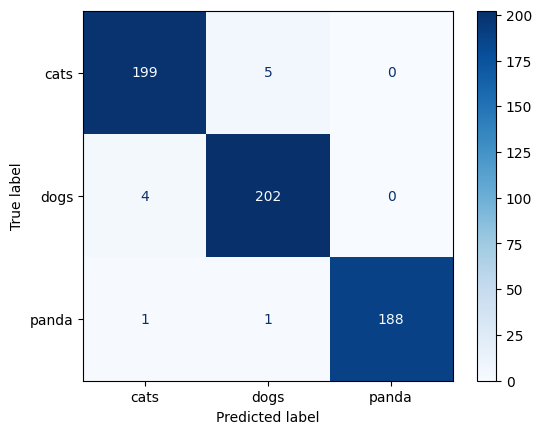

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model):
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloaders[TEST]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        test_loss = running_loss / dataset_sizes[TEST]
        test_acc = running_corrects.double() / dataset_sizes[TEST]

        print(f'Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}')

        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(cmap=plt.cm.Blues)
        plt.show()

evaluate_model(model)

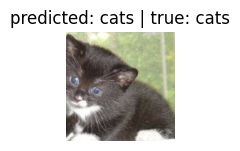

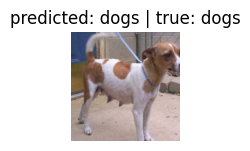

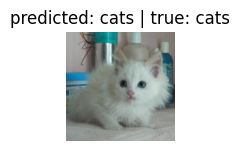

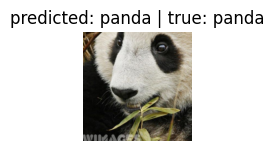

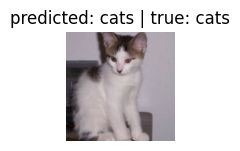

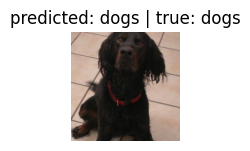

In [14]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders[TEST]):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]} | true: {class_names[labels[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

visualize_model(model)